# Het kiezen van een statistisch model
Statistiek <br>
Department of applied mathematics

**Wat** In deze opgave bekijken we een dataset. Op basis van een grafische interpretatie van de data kiezen we een collectie modelverdelingen. De parameter(s) van deze modelverdeling schatten we vervolgens met de methoden geintroduceerd in het college.
We vinden zo verzameling om de data te modelleren. We verifieren vervolgens hoe goed onze keuze is op basis van een bootstrap.

**Waarom** Serieuze statistiek doen we niet met een rekenmachine en datasets met $n = 10$. Datasets zijn groter, en de procedures werken dan net zo goed. Deze opdracht geeft enige oefening met het werken met een 'grotere' dataset. 

* * *


Voordat we starten vul naam en studentnummers in. Laadt daarna enige standaard bibliotheken door de volgende cell uit te voeren.

Namen en studentnummers:
| Namen            | studienummers | 
|:-----------------|:--------------|
| Ashley Haagsma   | 6277330         |
| Danielle Koopman | 6325166      |

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd
import math
from scipy import stats


Bepaal het laatste nummer van je studentnummer. Als je met twee bent, gooi een muntje om een van deze twee nummers er een uit te kiezen. Dit is het nummer van de dataset die je gaat analyseren. Zet deze toegewezen data set in je Python directory.
1. ***breuksterkte*** 
    48 onafhankelijke en gelijkverdeeld metingen van de belasting van gereedschap bij breuk (data in kilo's)
2. ***computerhours*** 
    Een steekproef van omvang 103 van het aantal uren per week achter de spelcomputer
3. ***golfdiesel***
	85 metingen van het diesel verbruik in liters per 100 km van een Golf diesel
4. ***heights***
	Een steekproef van omvang 55 van de lichaamslengte van vrouwen (metingen in inches)
5. ***inkomen*** 
	Een steekproef van omvang 87 van het jaarinkomen in euros, getrokken uit de belastingplichtigen(NL)
6. ***internetdelays***
	103 metingen van vertragingen (in milliseconden) gemeten tussen twee vaste bestemmingen
7. ***traceroute***
	109 waarnemingen van het aantal routers in het Internet tussen 2 random gekozen lokaties
8. ***tussentijden***
	Op een drukke provinciale weg zijn in een vaste richting 127 tussentijden gemeten tussen opeenvolgende auto's
9. ***verbruikBMW***
	48 metingen van het verbruik van een BMW R1200GS motorfiets; eenheid aantal liters per 100km
10. ***waterstand***
	Een steekproef van 150 waterstanden

Zet het gekozen `keuze.xlsx` bestand in dezelfde folder. Laadt de gekozen array. Dit kan je doen met (voor de matrix waterstand bijvoorbeeld):

In [18]:
data = np.loadtxt("breuksterkte.csv",skiprows=1,delimiter=",",usecols=[1])

## Opgave 1 a)
Maak een histogram uit de data. Dit kan je doen met commando `ax.hist()`. Gebruik bijvoorbeeld `bins = 'auto'` en `density = 'True'`. 

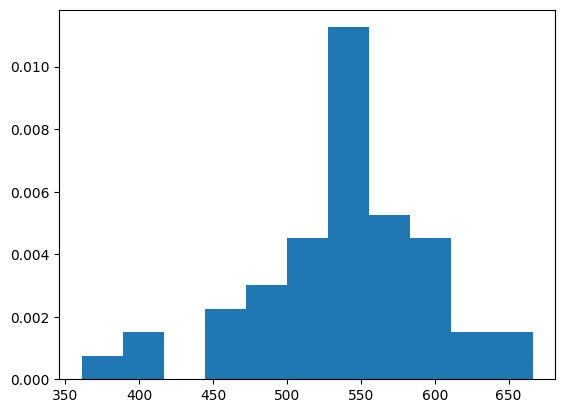

In [21]:
# Cell voor programmacode bij opgave 1a)

fig, ax = plt.subplots(1,1)
ax.hist(data,bins="auto",density="True")
plt.show()

# geef commando voor plotten

## Opgave 1 b)
Welke modelverdelingen zijn geschikt voor het modeleren van de data? Motiveer deze keuze op grond van fysische en/of statistische overwegingen en op basis van het histogram. Kies een verdeling uit onderstaande: 

_Normal, Exponential, Pareto, Rayleigh, Geometric, Binomial, Poisson_ 

Eventueel moet u de data verschuiven, bijvoorbeeld door de data te verminderen met het minimum. Indien je een verschuiving of normalisatie van de data toepast, geef dit onder aan
	
Schat de parameter(s) van de verdeling: zie hoofdstukken 17,19,20,21. Geef de schatting(en) expliciet. Waarom heb je deze schatter(s) gekozen?

Maak een plot waarin de dichtheid wordt geplot van de gekozen verdeling. Geef in dezelfde plot nogmaals het histogram weer. (Sanity check: Als het goed is komen het histogram en de dichtheid aardig overeen).

Om te beginnen is de belasting waarop gereedschap breekt een continu stochast op het domein (0,$\infty$) dus dan blijven alleen de continue verdelingen: normaal, exponentieel of Rayleigh nog over. Verder zullen de afwijkingen van het gemiddelde die in de data zichtbaar zijn komen van twee grote bronnen, namelijk de meetfouten die zitten in de meting van de kracht sterkte en de kleine afwijkingen van de daadwerkelijke maximale belasting die elk verschillend stuk gereedschap heeft. De meetfouten van een meetinstrument zijn gewoonlijk normaal verdeeld. De daadwerkelijke maximale belasting van een stuk gereedschap zal afwijken door microscopische structuur verschillen tussen verschillende stukken gereedschap, deze afwijkingen zullen normaal verdeeld zijn.

De meetfouten zijn $\sim N(0,\sigma_m^2)$ verdeeld. De daadwerkelijke maximale belasting is $\sim N(\mu,\sigma_b^2)$ verdeeld. De gemeten maximale belasting zal hiermee $\sim N(\mu,\sigma_m^2+\sigma_b^2)$ verdeeld. De te bepalen verdeling wordt hiermee $\sim N(\mu,\sigma^2)$.

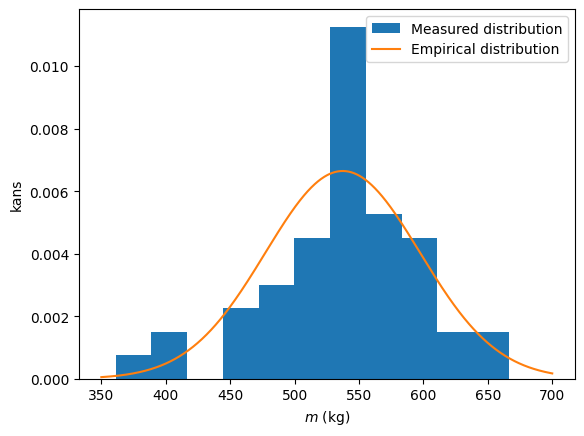

In [66]:
# Cell voor schatting parameters en het plotten van het histogram en de dichtheid.
def normal(x,mu,sigma): # create a gaussian to plot alongside the histogram
    macht = -0.5 *((x-mu)/sigma)**2
    return 1/np.sqrt(2*np.pi*sigma**2) * np.e**(macht)

mu = np.mean(data)
sigma = np.std(data)
x = np.linspace(350,700,1000)
verdeling = normal(x,mu,sigma)

fig, ax = plt.subplots(1,1)
ax.hist(data,bins="auto",density="True",label="Measured distribution")
ax.plot(x,verdeling,label="Empirical distribution")
plt.legend()
plt.xlabel("$m$ (kg)")
plt.ylabel("kans")
plt.legend()
plt.show()


## Opgave 1 c)

Als voorbereiding op opgave 2, vergelijken we ook de empirische verdelingsfunctie met de de verdelingsfunctie van de van de verdeling die gekozen is bij b). De empirische verdelingsfunctie is gegeven door
\begin{equation*}
F_n(a) = \frac{1}{n} \# \left\{i \, | \, x_i \leq a \right\},
\end{equation*}
waarbij $n$ de lengte van je data set is. Met andere woorden, $n*F_n(a)$ is het aantal datapunten dat kleiner of gelijk is aan $a$. 

<br>

Geef je code in het tweede blok hieronder. IN het eerstvolgende blok wordt de functie `empirical_cdf` gedefinieerd. Deze functie maakt uit de data twee vectoren `x_ecdf` en `y_ecdf`. De eerste bevat de unieke locaties waar de empirische verdelingsfunctie een sprong maakt, de tweede geeft de waarde van de empirische verdelingsfunctie in dat punt. Het resultaat kan dan geplot worden in blok 2 als de empische verdelingsfunctie met `np.step`. Vergelijk deze empirische verdelingsfunctie met de verdelingsfunctie van jullie gekozen verdeling.

In [59]:
# hoef je niet te wijzigen
def empirical_cdf(vector):
    
    n = vector.size
    sorted_vector = np.sort(vector)
    x_ecdf = np.array([sorted_vector[0]])
    y_ecdf = np.array([0])
    
    for i in range(n):
        if sorted_vector[i] == x_ecdf[-1]:
            y_ecdf[-1] = y_ecdf[-1] + 1/n
        else:
            x_ecdf = np.append(x_ecdf,sorted_vector[i])
            y_ecdf = np.append(y_ecdf,y_ecdf[-1] + 1/n)
    return x_ecdf,y_ecdf

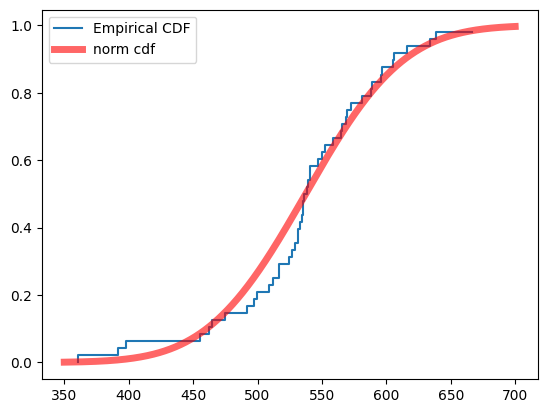

In [62]:
fig, ax = plt.subplots(1,1)


ax.step(*empirical_cdf(data),label="Empirical CDF")
ax.plot(x, stats.norm.cdf(x,loc=mu,scale=sigma),
       'r-', lw=5, alpha=0.6, label='norm cdf')
plt.legend()


# Geef de code voor het plotten van de verdelingsfunctie van jullie gekozen verdeling.

Text vraag: lijken de verdeling functies op elkaar?

De verdelings functie lijken redelijk op elkaar. Rechts van het gemiddelde volgt de data de geschatte verdeling heel goed. Links van het gemiddelde lijkt de helling van de data eerst minder dan die van de geschatte verdeling, daarna lijkt de helling juist hoger. Dit valt ook te zien in de verdeling dat links een groep datapunten met een vrij hoge frequentie is en daarna een groep missende data punten.

## Opgave 2 
We analyseren nu _hoe goed_ de schatting is. 
In het college hebben we gekeken naar hoe goed een schatter is met behulp van de mean-squared error. Maar dit ging er van uit dat we al wisten wat voor type verdeling we hadden. In deze situatie weten we ook dat niet.

In plaats van de mean-squared error, gaan we de empirische verdelingsfunctie met de verdeling die we hebben verkregen uit de bovenstaande procedure. We doen dit met behulp van de Kolmogorov-Smirnov afstand. In de context dat we een verdeling hebben met één geschatte parameter $\hat{\theta}$ is deze afstand gegeven door
\begin{equation*}
t_{ks} := \max_a \left| F_n(a) - F_{\hat{\theta}}(a) \right|.
\end{equation*}
Met andere woorden, $t_{KS}$ is de maximale verticale afstand tussen de 2 grafieken die jullie verkregen hebben bij 1c). Als zowel de geschatte verdeling, als de geschatte parameters, een goede fit zijn, dan is $t_{ks}$ klein, als de verdeling niet goed past vinden we een hoge waarde.

Gebruik de functie `stats.kstest` om de afstand $t_{ks}$ voor onze dataset te berekenen. Licht toe of deze waarde redelijk lijkt ten opzichte van wat je in opgave 1 hebt gezien.

In opgave 3 bepalen we wat een kleine of grote waarde voor $t_{ks}$ is. Onder de programmatekst staat een toelichting van de functie.

In de code hieronder roept `geom.cdf` de verdelingsfunctie ((cumulative) distribution function) van de geometrische verdeling aan. Voor je eigen verdeling kan je de benodigde vervanging vinden in de SciPy bibliotheek. Importeer de juiste verdeling uit _scipy.stats_. Zie https://docs.scipy.org/doc/scipy/reference/stats.html.

In [ ]:
# Zet de juiste verdeling in distribution.
# Hieronder hebben we de geometrische verdeling met p = 0.5 ingeladen. 
# In het algemeen zul je je verdeling moeten kiezen, en de parameters moeten schatten.

from scipy.stats import geom
distribution = geom(loc=0,p=0.5)

# Reken de KS afstand uit met de functie stats.kstest, bijvoorbeeld, stats.kstest(data, rv.cdf)[0]
# stats.kstest(data, rv.cdf) geeft twee outputs: probeer dat eens, de eerste output is de KS afstand, 
# de tweede output is een p waarde. Deze behandelen we niet in deze opgave.

KS_afstand_data = stats.kstest(data, distribution.cdf)[0]

print("The KS-distance equals {}".format(KS_afstand_data))

## Opgave 3
Voer een parametrische bootstrap uit op de Kolmogorov-Smirnov(KS) statistische grootheid (Zie paragraaf 18.3 uit het boek):
\begin{equation*}
\max_a \left|F_n(a) - F_{\hat{\theta}}(a)\right|. 
\end{equation*}
Gebruik hiervoor de functie `KS_distance` van Opgave 2. Gebruik voor het genereren van toevalsvariabelen de SciPy bibliotheek. Geometrische toevalsvariabelen worden bijvoorbeeld gegenereerd door `geom.rvs()`. Maak een histogram gemaakt op grond van 1000 gebootstrapte KS-afstanden en kruis daarin de waarde van $t_{ks}$ verkregen in Opgave 2 aan. Wat is jullie conclusie: is de gevonden verdeling uit 1 een goede beschrijving voor de dataset?

Merk op (sanity check voor je algoritme): de KS afstanden van de bootstrap zouden normaal gespoken niet boven de 0.2 moeten liggen.

In [ ]:
#Cell voor code bij opgave 3.


bootstrap_size = 1000


bootstrap_KS = np.array([])

for counter in range(bootstrap_size):
    # .... code
    #bootstrap_KS = np.append(bootstrap_KS, .... code )
    
    
#fig, ax = plt.subplots(1,1)
#ax.hist(bootstrap_KS ,density = True,bins='auto')
#plt.axvline(... ,c='red')  

Cell voor tekstuele uitwerking bij opgave 3.

## Laatste aanwijzigingen omtrent het inleveren

Zorg dat in dit verslag duidelijk en statistisch verantwoord antwoord is gegeven op _alle_ bovenstaande vragen. Maak van bovenstaande een pdf (klik op file en dan 'download as', kies pdf via latex).

Niet volledige of foute verslagen worden krijgen een tweede mogelijkheid tot inleveren.